In [2]:
import joblib
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    explained_variance_score
)

In [3]:
YEAR_START = 2024
YEAR_END = 2024
PATH_PARQUET = "data/2023-2025_integrated_data_train.parquet"

In [11]:
train_df = pq.read_table(PATH_PARQUET, filters=[
            ("time", ">=", pd.Timestamp(f"{YEAR_START}-01-01")),
            ("time", "<=", pd.Timestamp(f"{YEAR_END}-12-31")),
        ],).to_pandas()
train_df

,site_id,direction,year,month,day,hour,lat_flow,lon,total_count,obs_per_hour,...,district,gemeente,interval,datum_van,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count,description
0,1,in,2024,1,1,0,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
1,1,in,2024,1,1,1,50.916183,4.456122,3.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
2,1,in,2024,1,1,2,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
3,1,in,2024,1,1,3,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
4,1,in,2024,1,1,4,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2388711,143,out,2024,12,30,20,50.830662,3.262860,47.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
2388712,143,out,2024,12,30,21,50.830662,3.262860,43.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
2388713,143,out,2024,12,30,22,50.830662,3.262860,85.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
2388714,143,out,2024,12,30,23,50.830662,3.262860,48.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT


In [12]:
train_df["time"] = pd.to_datetime(train_df["time"])
train_df.set_index("time", inplace=True)

In [13]:
train_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2388716 entries, 2024-01-01 00:00:00 to 2024-12-31 00:00:00
Data columns (total 36 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   site_id                   int32  
 1   direction                 str    
 2   year                      int16  
 3   month                     int8   
 4   day                       int8   
 5   hour                      int8   
 6   lat_flow                  float32
 7   lon                       float32
 8   total_count               float32
 9   obs_per_hour              int64  
 10  temperature_2m            float64
 11  apparent_temperature      float64
 12  relative_humidity_2m      float64
 13  precipitation             float64
 14  rain                      float64
 15  snowfall                  float64
 16  wind_speed_10m            float64
 17  shortwave_radiation       float64
 18  direct_normal_irradiance  float64
 19  sunshine_duration         float64
 20  si

In [14]:
cols_to_drop = [
    "lat_meta", "long", "obs_per_hour",
    "site_nr", "naam", "domein", "wegnr", "district", "gemeente", "description", "interval", "datum_van", # site metadata
    "snowfall", "rain", "relative_humidity_2m", "wind_speed_10m", "temperature_2m", "direct_normal_irradiance", "sunshine_duration" # weather features
]
train_df_clean = train_df.drop(columns=[c for c in cols_to_drop if c in train_df.columns], inplace=False)

In [15]:
train_df.direction.unique()

<ArrowStringArray>
['in', 'out']
Length: 2, dtype: str

In [16]:
train_df_clean["direction_enc"] = (train_df_clean["direction"] == "in").astype(int)  # 1=in  0=out
train_df_clean.drop(columns=["direction"], inplace=True)

In [17]:
train_df_clean["day_of_week"] = train_df_clean.index.dayofweek
train_df_clean["is_weekend"]  = (train_df_clean.index.dayofweek >= 5).astype(int)

In [18]:
train_df_clean.isna().sum()

site_id                      0
year                         0
month                        0
day                          0
hour                         0
lat_flow                     0
lon                          0
total_count                  0
apparent_temperature         0
precipitation                0
shortwave_radiation          0
dist_nearest_station    576544
dist_nearest_school          0
school_count                 0
station_count                0
park_count                   0
direction_enc                0
day_of_week                  0
is_weekend                   0
dtype: int64

In [19]:
train_df_clean["site_dir_key"] = (
    train_df_clean["site_id"].astype(str) + "_" + train_df_clean["direction_enc"].astype(str)
)
unique_keys      = sorted(train_df_clean["site_dir_key"].unique())
site_dir_enc_map = {k: i for i, k in enumerate(unique_keys)}
train_df_clean["site_dir_enc"] = train_df_clean["site_dir_key"].map(site_dir_enc_map)

Encode site direction and site id as new unique identifier. The encoded sites are stored to be used later. The example encoded sites are shown below:

```
{'100_0': 0,
 '100_1': 1,
 '101_0': 2,
 '101_1': 3,
 '102_0': 4,
 '102_1': 5,
 ...
}
```

In [23]:
train_df_clean.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2388716 entries, 2024-01-01 00:00:00 to 2024-12-31 00:00:00
Data columns (total 21 columns):
 #   Column                Dtype  
---  ------                -----  
 0   site_id               int32  
 1   year                  int16  
 2   month                 int8   
 3   day                   int8   
 4   hour                  int8   
 5   lat_flow              float32
 6   lon                   float32
 7   total_count           float32
 8   apparent_temperature  float64
 9   precipitation         float64
 10  shortwave_radiation   float64
 11  dist_nearest_station  float64
 12  dist_nearest_school   float64
 13  school_count          int64  
 14  station_count         int64  
 15  park_count            int64  
 16  direction_enc         int64  
 17  day_of_week           int32  
 18  is_weekend            int64  
 19  site_dir_key          str    
 20  site_dir_enc          int64  
dtypes: float32(3), float64(5), int16(1), int32(2), int64(6)

## Global + By site XGB

In [8]:
TARGET = "total_count"
FEATURES = [
    'site_id', 'year', 'month', 'day', 'hour',
    'lat_flow','lon',
    'apparent_temperature', 'precipitation', 'shortwave_radiation',
    'dist_nearest_station', 'dist_nearest_school','school_count', 'station_count', 'park_count',
    'direction_enc', 'day_of_week', 'is_weekend',
    'site_mean_count', 'site_hour_mean_count','site_dow_mean_count', 'site_month_mean_count',
    'site_dir_enc', 'site_dir_mean_count',
]
MODEL_OUTPUT_DIR = "2024_training_model_without_weather_features"

In [9]:
def apply_encodings(df, encodings):
    df = df.copy()

    df["site_mean_count"] = df["site_id"].map(encodings["site_mean"])
    df["site_hour_mean_count"] = df.set_index(["site_id", "direction_enc", "hour"]).index.map(encodings["site_hour_mean"])
    df["site_dow_mean_count"] = df.set_index(["site_id", "direction_enc", "day_of_week"]).index.map(encodings["site_dow_mean"])
    df["site_month_mean_count"] = df.set_index(["site_id", "direction_enc", "month"]).index.map(encodings["site_month_mean"])
    df["site_dir_mean_count"] = df["site_dir_enc"].map(encodings["site_dir_mean"])
 
    enc_cols = [
        "site_mean_count", 
        "site_hour_mean_count",
        "site_dow_mean_count", 
        "site_month_mean_count", 
        "site_dir_mean_count"]
    df[enc_cols] = df[enc_cols].fillna(encodings["global_mean"])
    return df

In [23]:
site_mean = train_df_clean.groupby("site_id")[TARGET].mean()
site_hour_mean = train_df_clean.groupby(["site_id", "direction_enc", "hour"])[TARGET].mean()
site_dow_mean = train_df_clean.groupby(["site_id", "direction_enc", "day_of_week"])[TARGET].mean()
site_month_mean = train_df_clean.groupby(["site_id", "direction_enc", "month"])[TARGET].mean()
site_dir_mean = train_df_clean.groupby("site_dir_enc")[TARGET].mean()
global_mean = float(site_mean.mean())

mean_encodings = {
    "site_mean": site_mean,
    "site_hour_mean": site_hour_mean,
    "site_dow_mean": site_dow_mean,
    "site_month_mean": site_month_mean,
    "site_dir_mean": site_dir_mean,
    "global_mean": global_mean,
}
 
train_df_clean = apply_encodings(train_df_clean, mean_encodings)

In [ ]:
X_train = train_df_clean[FEATURES]
y_train = train_df_clean[TARGET]
 
print(f"Training rows : {len(X_train):,}")
print(f"Features      : {len(FEATURES)}")
 
final_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,    
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
 
final_model.fit(X_train, y_train, verbose=100)

Training rows : 2,388,716
Features      : 21


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [6]:
import plotly.express as px

gain = final_model.get_booster().get_score(importance_type="gain")
sorted_items = sorted(gain.items(), key=lambda x: x[1])[-15:]
feat = [item[0] for item in sorted_items]
vals = [item[1] for item in sorted_items]

fig = px.bar(
    x=vals,
    y=feat,
    orientation="h",
    color=vals,
    color_continuous_scale="Viridis",
    labels={"x": "Importance Score", "y": "Features", "color": "Gain"},
    title="Top 15 Feature Importances - Without Weather Features",
)

fig.update_layout(template="simple_white", coloraxis_showscale=False)
fig.update_yaxes(tickmode="linear")

fig.show()

Saving to encodings and final model for test set application later use.

In [31]:
joblib.dump(final_model, f"models/final_xgb_model_{MODEL_OUTPUT_DIR}.pkl")
 
# joblib.dump(mean_encodings, "models/mean_encodings.pkl")
# joblib.dump(site_dir_enc_map, "models/site_dir_enc_map.pkl")

['models/final_xgb_model_2024_training_model_without_weather_features.pkl']

#### Validation

For the training model of 2024 data, a validation is made by 2025 data.

In [7]:
validation_df = pq.read_table(PATH_PARQUET, filters=[
    ("time", ">=", pd.Timestamp("2025-01-01")),
    ("time", "<=", pd.Timestamp("2025-12-31")),
]).to_pandas()
validation_df["time"] = pd.to_datetime(validation_df["time"])
validation_df.set_index("time", inplace=True)

In [ ]:
final_model = joblib.load("models/final_xgb_model_2024_training_model.pkl")
mean_encodings = joblib.load("models/mean_encodings.pkl")
site_dir_enc_map = joblib.load("models/site_dir_enc_map.pkl")

In [21]:
val_df = validation_df.copy()
val_df["direction_enc"] = (val_df["direction"] == "in").astype(int)  # 1=in  0=out
val_df.drop(columns=["direction"], inplace=True)
val_df["day_of_week"] = val_df.index.dayofweek
val_df["is_weekend"]  = (val_df.index.dayofweek >= 5).astype(int)

val_df["site_dir_key"] = val_df["site_id"].astype(str) + "_" + val_df["direction_enc"].astype(str)
val_df["site_dir_enc"] = val_df["site_dir_key"].map(site_dir_enc_map)

In [24]:
val_df = apply_encodings(val_df, mean_encodings)

In [25]:
X_val = val_df[FEATURES]
y_val = val_df[TARGET]

preds = final_model.predict(X_val)
preds_non_zero = np.clip(preds, 0, None)

After predicting the validation data, error metrics are calculated to evaluate the model performance.

In [26]:
print(f"MAE               : {mean_absolute_error(y_val, preds_non_zero):.2f}")
print(f"RMSE              : {root_mean_squared_error(y_val, preds_non_zero):.2f}")
print(f"R²                : {r2_score(y_val, preds_non_zero):.4f}")
print(f"Explained Variance: {explained_variance_score(y_val, preds_non_zero):.4f}")

MAE               : 4.52
RMSE              : 13.63
R²                : 0.7617
Explained Variance: 0.7625


In [27]:
preds.shape, y_val.shape

((2355385,), (2355385,))

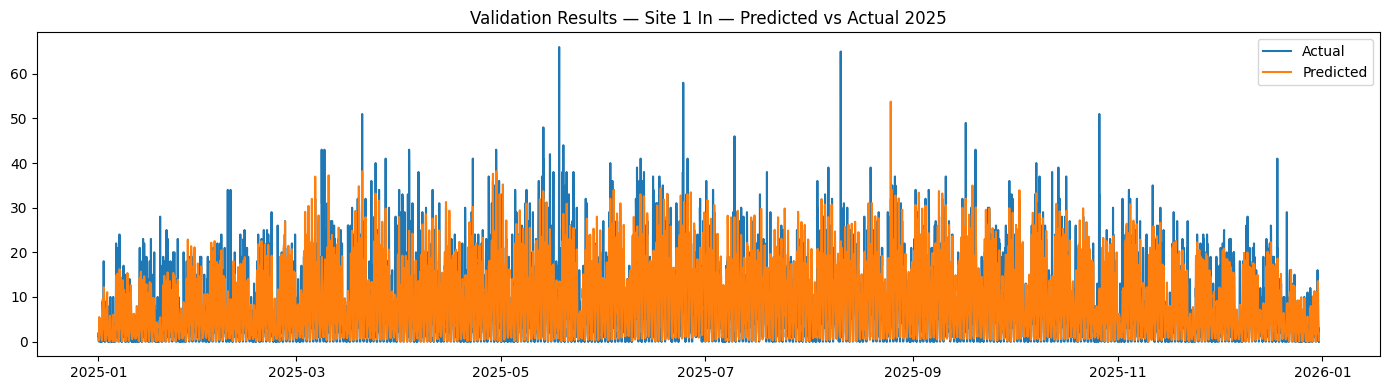

In [28]:
site = 1
direction = "in"

mask = (val_df["site_id"] == site) & (val_df["direction_enc"] == (1 if direction == "in" else 0))
site_df = pd.DataFrame({
    "actual":    y_val[mask].values,
    "predicted": preds_non_zero[mask]
}, index=y_val[mask].index)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(site_df.index, site_df["actual"],    label="Actual")
ax.plot(site_df.index, site_df["predicted"], label="Predicted")
ax.set_title(f"Validation Results — Site {site} {direction.capitalize()} — Predicted vs Actual 2025")
ax.legend()
plt.tight_layout()
plt.show()

## Test set predictions for final model - 2026

In [2]:
PATH_PARQUET_TEST_WITH_FORECAST = "data/2025_2026_forecast_integrated_data_test.parquet"
PATH_PARQUET_TEST_WITH_ACTUALS = "data/2025_2026_actual_integrated_data_test.parquet" 
TEST_YEAR = 2026

### Checking weather data for test and training sets

Comparing test and train segments for which weather dataset is used: actual weather data for train segments, forecasted weather data for test segments.

In [ ]:
test_df = pq.read_table(PATH_PARQUET_TEST_WITH_FORECAST, filters=[
            ("time", ">=", pd.Timestamp(f"2025-01-01")),
            ("time", "<=", pd.Timestamp(f"2025-12-31")),
        ],).to_pandas()
test_df["time"] = pd.to_datetime(test_df["time"])
test_df.set_index("time", inplace=True)

train_df_2025 = pq.read_table(PATH_PARQUET, filters=[("time", ">=", pd.Timestamp(f"2025-01-01"))],).to_pandas()
train_df_2025["time"] = pd.to_datetime(train_df_2025["time"])
train_df_2025.set_index("time", inplace=True)

actual_weather_2025 = pq.read_table("data/weather_data_2023-2026.parquet", filters=[
    ("time", ">=", pd.Timestamp(f"2025-01-01")),
    ("time", "<=", pd.Timestamp(f"2025-12-31"))
]).to_pandas()

fcts_weather_2025 = pq.read_table("data/weather_forecast_data_2023-2026.parquet", filters=[
    ("time", ">=", pd.Timestamp(f"2025-01-01")),
    ("time", "<=", pd.Timestamp(f"2025-12-31"))
]).to_pandas()

In [ ]:
from functools import reduce

year = 2025
train_temp = (
    train_df_2025[train_df_2025.index.year == year][["site_id", "temperature_2m"]]
    .reset_index()
    .rename(columns={"temperature_2m": "train_temperature_2m"})
)
test_temp = (
    test_df[test_df.index.year == year][["site_id", "temperature_2m"]]
    .reset_index()
    .rename(columns={"temperature_2m": "test_temperature_2m"})
)
actual_temp = (
    actual_weather_2025[actual_weather_2025.index.year == year][
        ["site_id", "temperature_2m"]
    ]
    .reset_index()
    .rename(columns={"temperature_2m": "actual_temperature_2m"})
)
fcst_temp = (
    fcts_weather_2025[fcts_weather_2025.index.year == year][
        ["site_id", "temperature_2m"]
    ]
    .reset_index()
    .rename(columns={"temperature_2m": "fcst_temperature_2m"})
)

data_frames = [train_temp, test_temp, actual_temp, fcst_temp]
df_merged = reduce(
    lambda left, right: pd.merge(left, right, on=["time", "site_id"], how="inner"),
    data_frames,
)

df_merged

,time,site_id,train_temperature_2m,test_temperature_2m,actual_temperature_2m,fcst_temperature_2m
0,2025-01-01 00:00:00,1,6.60,5.5955,6.60,5.5955
1,2025-01-01 00:00:00,1,6.60,5.5955,6.60,5.5955
2,2025-01-01 01:00:00,1,7.15,5.5455,7.15,5.5455
3,2025-01-01 01:00:00,1,7.15,5.5455,7.15,5.5455
4,2025-01-01 02:00:00,1,7.30,5.7955,7.30,5.7955
...,...,...,...,...,...,...
4710566,2025-12-30 22:00:00,143,1.85,1.1195,1.85,1.1195
4710567,2025-12-30 23:00:00,143,2.00,1.1695,2.00,1.1695
4710568,2025-12-30 23:00:00,143,2.00,1.1695,2.00,1.1695
4710569,2025-12-31 00:00:00,143,1.80,0.7695,1.80,0.7695


From the table above, it confirms that the training dataset is created with the actual hsitorical waether data, while the test data is created with the historical forecast weather data. This is important to note as it may impact the model performance, and we should be cautious when interpreting the results.

### Setting up test set

In [8]:
test_df = pq.read_table(PATH_PARQUET_TEST_WITH_FORECAST, filters=[
            ("time", ">=", pd.Timestamp(f"{TEST_YEAR}-01-01")),
            ("time", "<=", pd.Timestamp(f"{TEST_YEAR}-12-31")),
        ],).to_pandas()
test_df

,site_id,direction,year,month,day,hour,lat_flow,lon,total_count,obs_per_hour,...,district,gemeente,interval,datum_van,dist_nearest_station,dist_nearest_school,school_count,station_count,park_count,description
0,1,in,2026,1,1,0,50.916183,4.456122,0.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
1,1,in,2026,1,1,1,50.916183,4.456122,1.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
2,1,in,2026,1,1,2,50.916183,4.456122,2.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
3,1,in,2026,1,1,3,50.916183,4.456122,1.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
4,1,in,2026,1,1,4,50.916183,4.456122,2.0,4,...,AWV212,Machelen,15,2019-08-22,2762.772259,1036.993839,0,0,0,Machelen Cyclists rich. Brucargo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379081,143,out,2026,2,28,19,50.830662,3.262860,73.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
379082,143,out,2026,2,28,20,50.830662,3.262860,51.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
379083,143,out,2026,2,28,21,50.830662,3.262860,46.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT
379084,143,out,2026,2,28,22,50.830662,3.262860,52.0,4,...,NaN,Kortrijk,15,2023-12-08,705.048395,409.296280,4,0,12,YTH17062596 Cyclists OUT


In [9]:
test_df["time"] = pd.to_datetime(test_df["time"])
test_df.set_index("time", inplace=True)
test_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 379086 entries, 2026-01-01 00:00:00 to 2026-02-28 23:00:00
Data columns (total 36 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   site_id                   379086 non-null  int32  
 1   direction                 379086 non-null  str    
 2   year                      379086 non-null  int16  
 3   month                     379086 non-null  int8   
 4   day                       379086 non-null  int8   
 5   hour                      379086 non-null  int8   
 6   lat_flow                  379086 non-null  float32
 7   lon                       379086 non-null  float32
 8   total_count               379086 non-null  float32
 9   obs_per_hour              379086 non-null  int64  
 10  temperature_2m            379086 non-null  float64
 11  apparent_temperature      379086 non-null  float64
 12  relative_humidity_2m      379086 non-null  float64
 13  precipitation        

In [10]:
final_model = joblib.load("models/final_xgb_model_2024-2025_training_model.pkl")
mean_encodings = joblib.load("models/mean_encodings.pkl")
site_dir_enc_map = joblib.load("models/site_dir_enc_map.pkl")

In [11]:
test_df_clean = test_df.copy()

test_df_clean["direction_enc"] = (test_df_clean["direction"] == "in").astype(int)  # 1=in  0=out
test_df_clean.drop(columns=["direction"], inplace=True)
test_df_clean["day_of_week"] = test_df_clean.index.dayofweek
test_df_clean["is_weekend"]  = (test_df_clean.index.dayofweek >= 5).astype(int)

test_df_clean["site_dir_key"] = test_df_clean["site_id"].astype(str) + "_" + test_df_clean["direction_enc"].astype(str)
test_df_clean["site_dir_enc"] = test_df_clean["site_dir_key"].map(site_dir_enc_map)

In [12]:
test_df_clean = apply_encodings(test_df_clean, mean_encodings)

### Testing results

In [13]:
X_test = test_df_clean[FEATURES]
y_test = test_df_clean[TARGET]

preds_test_with_forecasts = final_model.predict(X_test)

In [ ]:
preds_test_with_forecasts_non_zero = np.clip(preds_test_with_forecasts, 0, None)
print(f"MAE  : {mean_absolute_error(y_test, preds_test_with_forecasts_non_zero):.2f}")
print(f"RMSE : {root_mean_squared_error(y_test, preds_test_with_forecasts_non_zero):.2f}")
print(f"R²   : {r2_score(y_test, preds_test_with_forecasts_non_zero):.4f}")

MAE  : 3.12
RMSE : 8.31
R²   : 0.8640


In [21]:
3.08 - 3.12

-0.040000000000000036

### Testing results with actual weather data

In [15]:
test_df_with_actuals = pq.read_table(PATH_PARQUET_TEST_WITH_ACTUALS, filters=[
    ("time", ">=", pd.Timestamp(f"{TEST_YEAR}-01-01")),
    ("time", "<=", pd.Timestamp(f"{TEST_YEAR}-12-31"))
]).to_pandas()
test_df_with_actuals["time"] = pd.to_datetime(test_df_with_actuals["time"])
test_df_with_actuals.set_index("time", inplace=True)

In [16]:
test_df_clean_with_actuals = test_df_with_actuals.copy()

test_df_clean_with_actuals["direction_enc"] = (test_df_clean_with_actuals["direction"] == "in").astype(int)  # 1=in  0=out
test_df_clean_with_actuals.drop(columns=["direction"], inplace=True)
test_df_clean_with_actuals["day_of_week"] = test_df_clean_with_actuals.index.dayofweek
test_df_clean_with_actuals["is_weekend"]  = (test_df_clean_with_actuals.index.dayofweek >= 5).astype(int)

test_df_clean_with_actuals["site_dir_key"] = test_df_clean_with_actuals["site_id"].astype(str) + "_" + test_df_clean_with_actuals["direction_enc"].astype(str)
test_df_clean_with_actuals["site_dir_enc"] = test_df_clean_with_actuals["site_dir_key"].map(site_dir_enc_map)

test_df_clean_with_actuals = apply_encodings(test_df_clean_with_actuals, mean_encodings)

In [17]:
X_test_with_actuals = test_df_clean_with_actuals[FEATURES]
y_test_with_actuals = test_df_clean_with_actuals[TARGET]

preds_test_with_actuals = final_model.predict(X_test_with_actuals)

In [18]:
preds_test_with_actuals_non_zero = np.clip(preds_test_with_actuals, 0, None)
print(f"MAE  : {mean_absolute_error(y_test_with_actuals, preds_test_with_actuals_non_zero):.2f}")
print(f"RMSE : {root_mean_squared_error(y_test_with_actuals, preds_test_with_actuals_non_zero):.2f}")
print(f"R²   : {r2_score(y_test_with_actuals, preds_test_with_actuals_non_zero):.4f}")

MAE  : 3.08
RMSE : 8.14
R²   : 0.8696


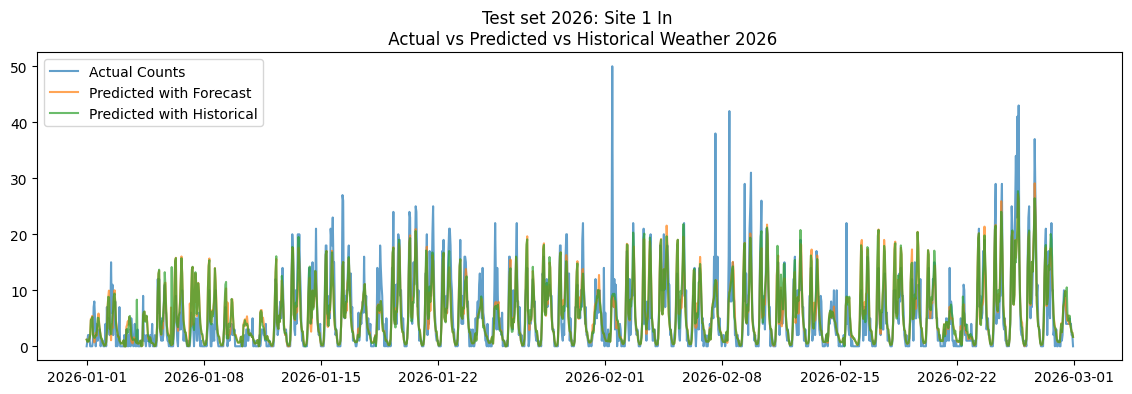

In [23]:
site = 1
direction = "in"

mask = (test_df_clean["site_id"] == site) & (test_df_clean["direction_enc"] == (1 if direction == "in" else 0))
site_df = pd.DataFrame({
    "actual counts":    y_test[mask].values,
    "predicted - with forecast": preds_test_with_forecasts_non_zero[mask],
    "predicted - with actuals": preds_test_with_actuals_non_zero[mask]
}, index=y_test[mask].index)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(site_df.index, site_df["actual counts"], label="Actual Counts", alpha=0.7)
ax.plot(site_df.index, site_df["predicted - with forecast"], label="Predicted with Forecast", alpha=0.7)
ax.plot(site_df.index, site_df["predicted - with actuals"], label="Predicted with Historical", alpha=0.7)
ax.set_title(f"Test set 2026: Site {site} {direction.capitalize()} \n Actual vs Predicted vs Historical Weather 2026")
ax.legend()
# plt.tight_layout()
plt.show()

### Resiliency analysis

A perfect weather is defined as constant temperature at mean temperature per site, no precipitation, and no wind. This is a hypothetical scenario to evaluate the model performance under ideal weather conditions.

In [18]:
perfect_weather_df = test_df_clean.copy()

perfect_weather_df["precipitation"] = 0
perfect_weather_df["wind_speed_10m"] = 0
perfect_weather_df["temperature_2m"] = perfect_weather_df.groupby("site_id")["temperature_2m"].transform("mean")
perfect_weather_df["apparent_temperature"]= perfect_weather_df.groupby("site_id")["apparent_temperature"].transform("mean")

X_test_perfect = perfect_weather_df[FEATURES]
y_test_perfect = perfect_weather_df[TARGET]

preds_perfect = np.clip(final_model.predict(X_test_perfect), 0, None)

In [19]:
print(f"MAE               : {mean_absolute_error(y_test_perfect, preds_perfect):.2f}")
print(f"RMSE              : {root_mean_squared_error(y_test_perfect, preds_perfect):.2f}")
print(f"R²                : {r2_score(y_test_perfect, preds_perfect):.4f}")
print(f"Explained Variance: {explained_variance_score(y_test_perfect, preds_perfect):.4f}")

MAE               : 3.29
RMSE              : 8.64
R²                : 0.8531
Explained Variance: 0.8532


### Saving predictions for test set application later use

In [20]:
results_df = pd.DataFrame({
    "site_id":          test_df["site_id"].values,
    "direction":        test_df["direction"].values,
    "actual":           y_test,
    "predicted":        preds_test_with_forecasts_non_zero,
    "predicted_perfect": preds_perfect,
}, index=test_df.index)
results_df

,site_id,direction,actual,predicted,predicted_perfect
time,,,,,
2026-01-01 00:00:00,1,in,0.0,1.187564,1.264637
2026-01-01 01:00:00,1,in,1.0,0.844721,0.917989
2026-01-01 02:00:00,1,in,2.0,0.845639,0.918907
2026-01-01 03:00:00,1,in,1.0,0.896674,0.969942
2026-01-01 04:00:00,1,in,2.0,1.412202,1.484799
...,...,...,...,...,...
2026-02-28 19:00:00,143,out,73.0,70.773178,70.571747
2026-02-28 20:00:00,143,out,51.0,55.622078,54.262695
2026-02-28 21:00:00,143,out,46.0,49.844547,50.183624


In [31]:
demo_range = ["2026-02-22", "2026-03-01"]
results_df_demo = results_df[results_df.index.isin(pd.date_range(pd.to_datetime(demo_range[0]), pd.to_datetime(demo_range[1]), freq="h"))]
results_df_demo

,site_id,direction,actual,predicted,predicted_perfect
time,,,,,
2026-02-22 00:00:00,1,in,0.0,1.074379,1.191985
2026-02-22 01:00:00,1,in,0.0,0.797859,0.847990
2026-02-22 02:00:00,1,in,0.0,0.793265,0.846965
2026-02-22 03:00:00,1,in,0.0,0.913680,0.842304
2026-02-22 04:00:00,1,in,0.0,0.809616,0.834218
...,...,...,...,...,...
2026-02-28 19:00:00,143,out,73.0,70.773178,70.571747
2026-02-28 20:00:00,143,out,51.0,55.622078,54.262695
2026-02-28 21:00:00,143,out,46.0,49.844547,50.183624


In [32]:
results_df_demo.to_csv("data/results_df_demo.csv", index=True)